<a href="https://colab.research.google.com/github/pxtroniwnl/hearth-attack-classification/blob/main/HearthDiseaseATTACK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Attack Prediction: Machine Learning Workflow

![Machine Learning](https://img.shields.io/badge/Machine%20Learning-Scikit--learn-orange?style=for-the-badge&logo=scikit-learn)
![Python](https://img.shields.io/badge/Python-3.x-blue?style=for-the-badge&logo=python)
![Status](https://img.shields.io/badge/Status-Completed-success?style=for-the-badge)

## 📌 Descripción del Proyecto
Este proyecto se enfoca en la creación de un sistema de clasificación binaria para predecir la probabilidad de ataques cardíacos basándose en indicadores clínicos y fisiológicos. El flujo de trabajo abarca desde el **Análisis Exploratorio de Datos (EDA)** hasta la implementación de modelos de aprendizaje supervisado.

> **Nota:** Este notebook fue preparado originalmente para el Machine Learning Bootcamp de **Global AI Hub** (Live Stream en YouTube).

---

## 📊 Diccionario de Datos
El dataset contiene atributos críticos para la salud cardiovascular. A continuación, se detallan las variables clave:

| Variable | Descripción | Valores / Unidades |
| :--- | :--- | :--- |
| **Age** | Edad del paciente | Años |
| **Sex** | Género | 1 = Masc; 0 = Fem |
| **CP** | Tipo de dolor de pecho | 1: Angina típica, 2: Atípica, 3: No-anginal, 4: Asintomático |
| **Trtbps** | Presión arterial en reposo | mm Hg |
| **Chol** | Colesterol sérico | mg/dl |
| **Fbs** | Azúcar en sangre en ayunas | 1: > 120 mg/dl; 0: <= 120 |
| **Rest_ecg** | Resultados electrocardiográficos | 0: Normal, 1: Anomalía ST-T, 2: Hipertrofia ventricular |
| **Thalachh** | Frecuencia cardíaca máxima | bpm |
| **Exng** | Angina inducida por ejercicio | 1: Sí; 0: No |
| **Oldpeak** | Depresión del ST inducida por ejercicio | Medida numérica |
| **Slp** | Pendiente del segmento ST pico | 0: Ascendente, 1: Plano, 2: Descendente |
| **Caa** | Número de vasos principales | Rango (0-4) |
| **Thall** | Resultado de prueba de talio | 0 a 3 |
| **Target** | **Variable Objetivo** | **0: Menor riesgo; 1: Mayor riesgo** |

---

## 🚀 Fases del Proyecto

### 1. Exploración y Visualización (EDA) 🔍
* **Inspección Estadística:** Análisis de tendencia central y dispersión de los datos.
* **Análisis de Correlación:** Uso de mapas de calor para identificar variables con mayor impacto en el riesgo cardíaco.
* **Distribuciones:** Visualización de `Age`, `Trtbps` y `Chol` mediante histogramas y boxplots para detectar sesgos.

### 2. Ingeniería de Características (Feature Engineering) 🛠️
* **Limpieza de Datos:** Identificación y manejo de valores nulos o inconsistentes.
* **Tratamiento de Outliers:** Manejo de valores atípicos en presión arterial y colesterol para mejorar la calidad del modelo.
* **Codificación y Escalado:** Transformación de variables categóricas (Encoding) y estandarización de variables numéricas (Scaling).

### 3. Modelado y Evaluación 🤖
Se implementaron y compararon los siguientes modelos de clasificación:
* **Logistic Regression** (Línea base).
* **K-Nearest Neighbors (KNN)**.
* **Decision Tree**.

La evaluación se centró en métricas de precisión y recall para determinar la capacidad del modelo en identificar casos de alto riesgo.

---

## 📈 Trabajo Futuro (Roadmap)
Para mejorar el rendimiento del sistema, se proponen las siguientes etapas:
- [ ] **Hyperparameter Tuning:** Aplicar `Grid Search` o `Random Search` para optimizar parámetros.
- [ ] **Modelos Avanzados:** Probar con ensambles como **Random Forest**, **XGBoost** o **Gradient Boosting**.
- [ ] **Explicabilidad (XAI):** Implementar valores **SHAP** para interpretar las decisiones del modelo de forma clínica.

---

## 🔗 Recursos
* **Dataset:** [Kaggle - Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
* **Librerías principales:** Pandas, Numpy, Scikit-learn, Seaborn, Matplotlib.

---

# Carga de Datos

In [3]:
import pandas as pd

df = pd.read_csv("/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Correlaciones

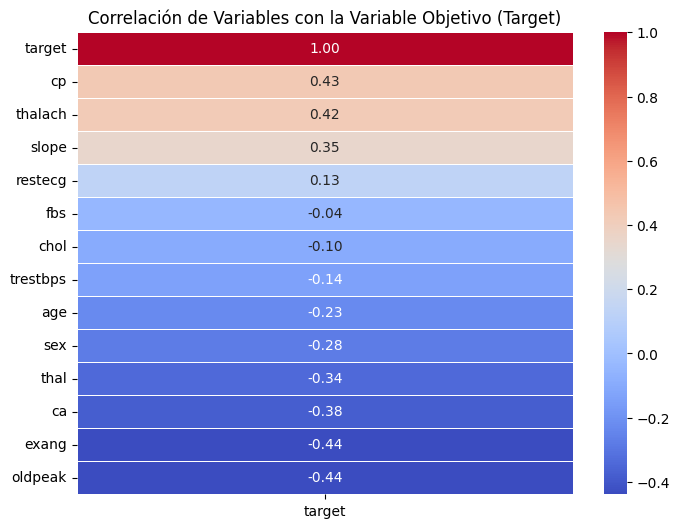

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()

target_corr = corr_matrix['target'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlación de Variables con la Variable Objetivo (Target)')
plt.show()

## Distribuciones

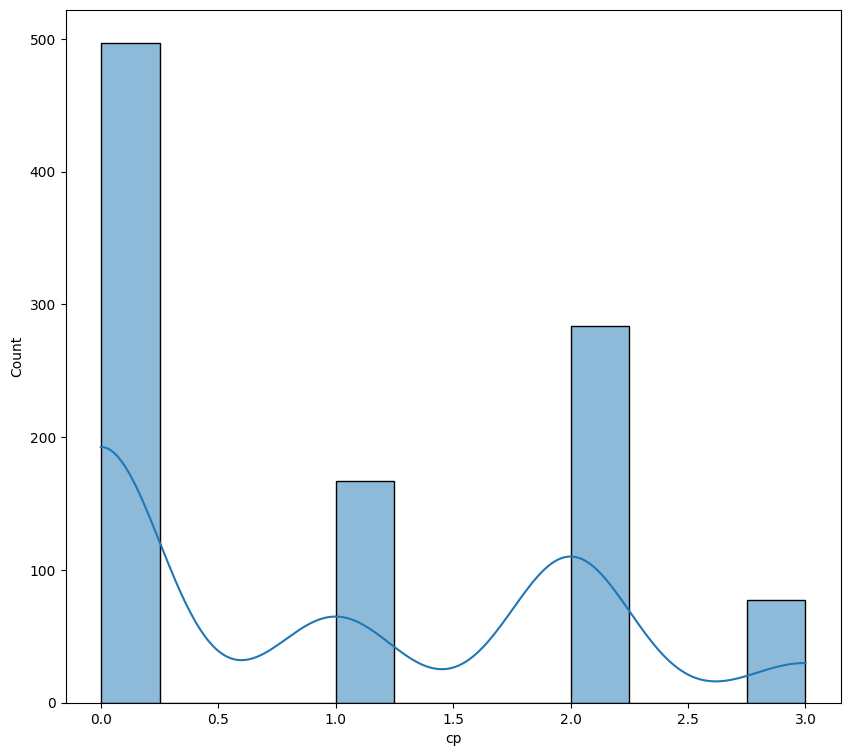

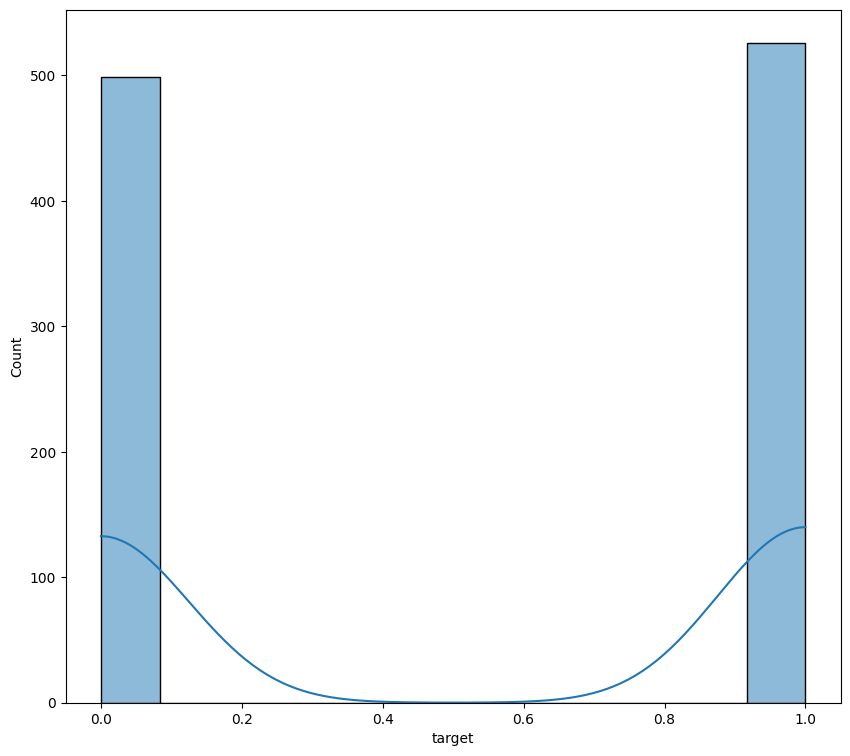

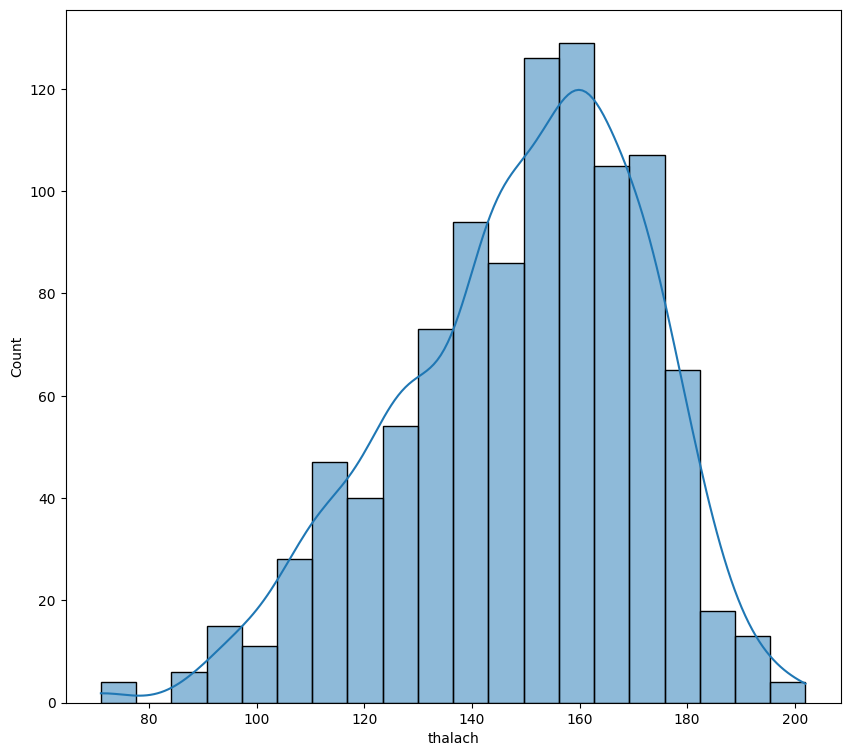

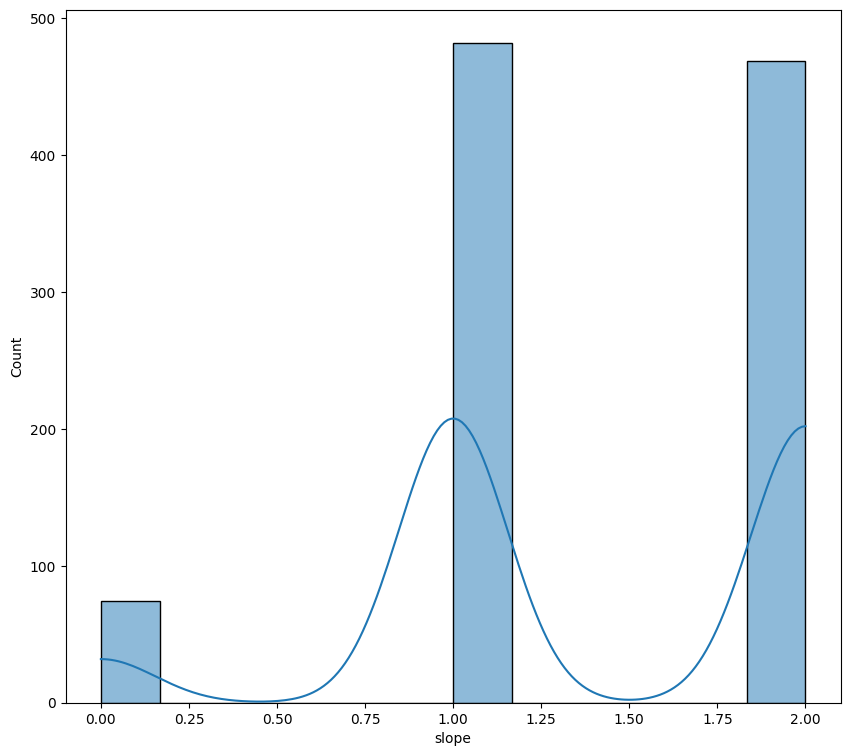

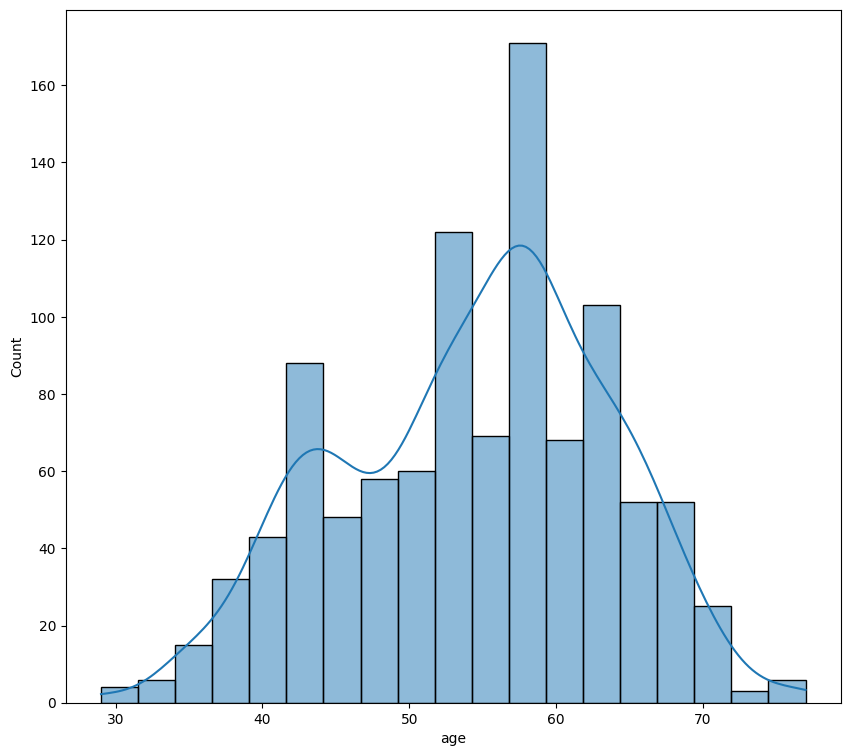

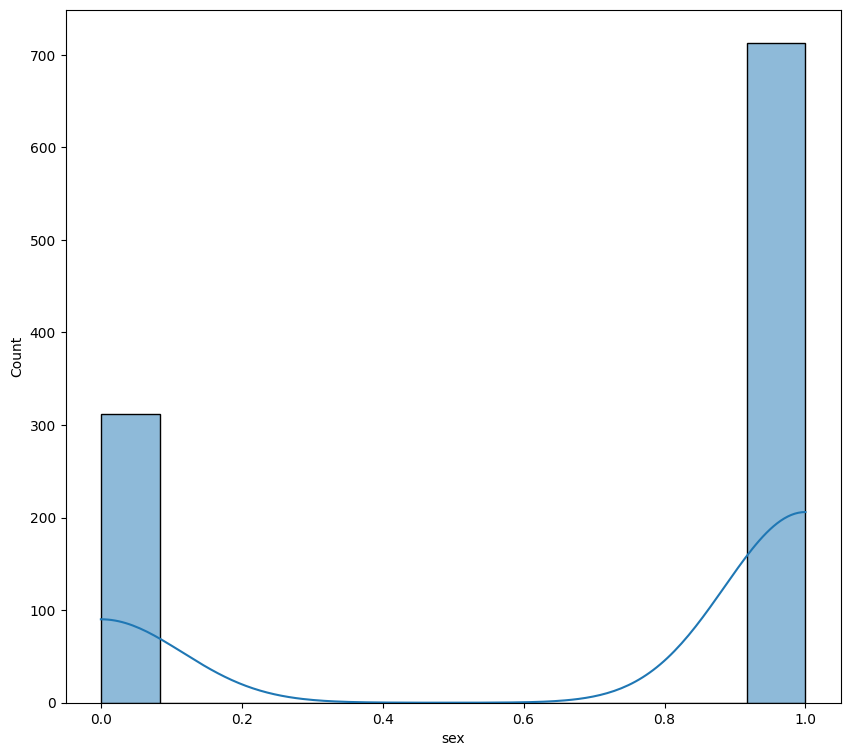

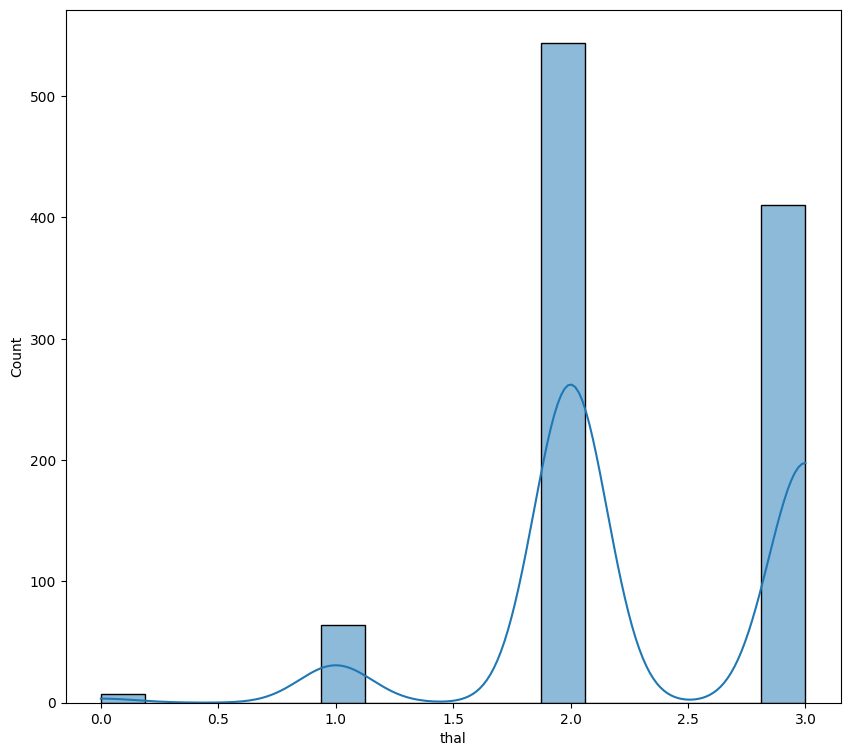

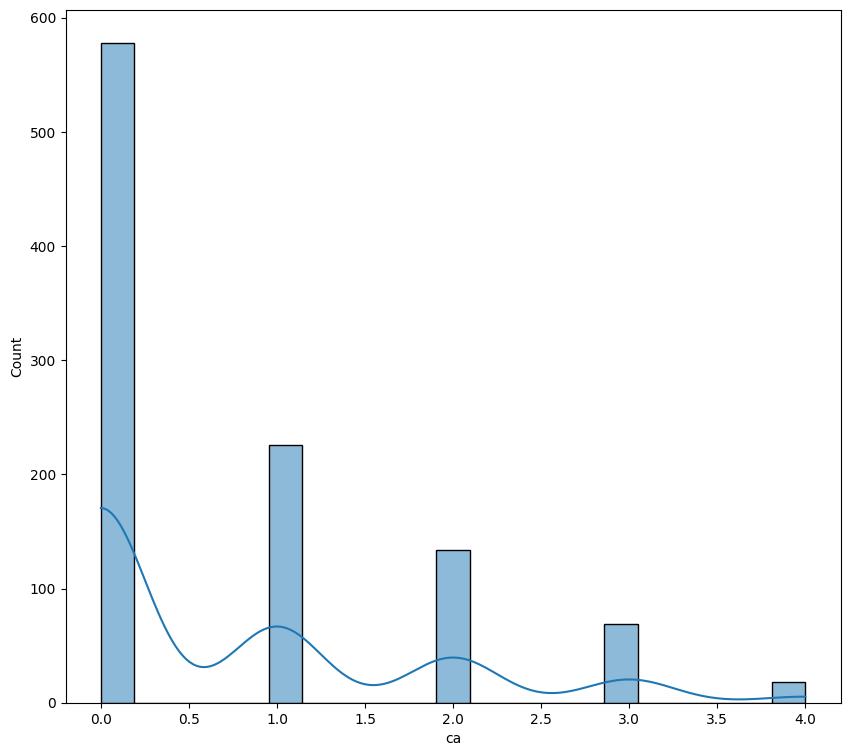

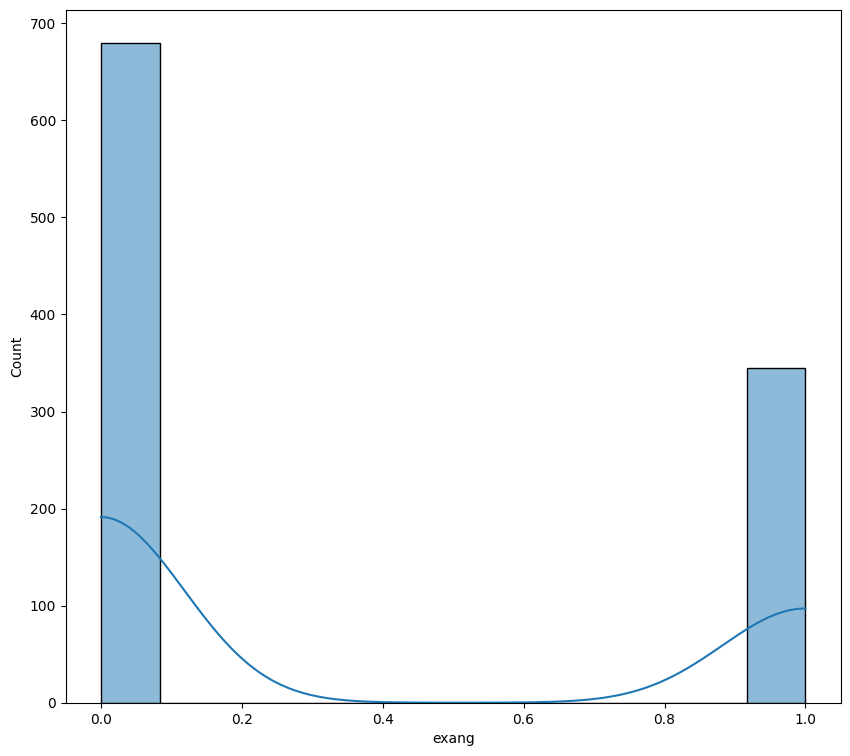

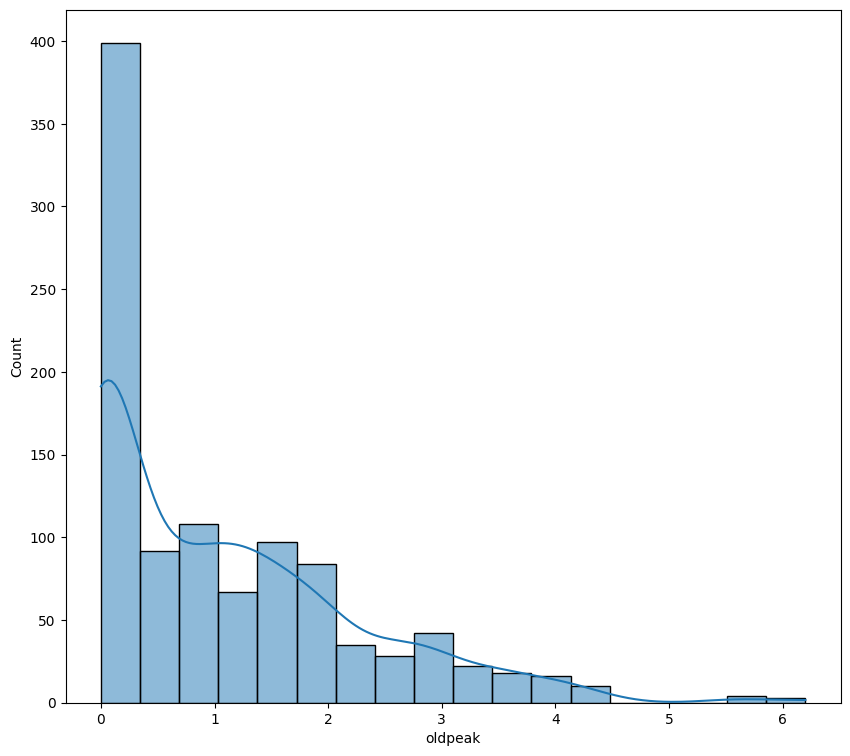

In [7]:
import seaborn as sns

features= ["cp","target","thalach","slope","age","sex","thal","ca","exang","oldpeak"]

for feature in features:
  plt.figure(figsize=(10,9))
  sns.histplot(data=df,x=feature,kde=True)
  plt.show()

Vemos que las clases entre gente que se le produce ataque al corazon y no ataque estan balanceadas por lo que a la hora de particionar el dataset en train test val no tendremos que estratificar entre la clase a predecir vemos ademas que algunas variables como la de la edad son un poco normales lo que nos coviene y hay varias clases que son categorias unas binarias y otras de mas por lo que probablemente tendremos que hacer un encoding

#  Limpieza y Feature Engineering

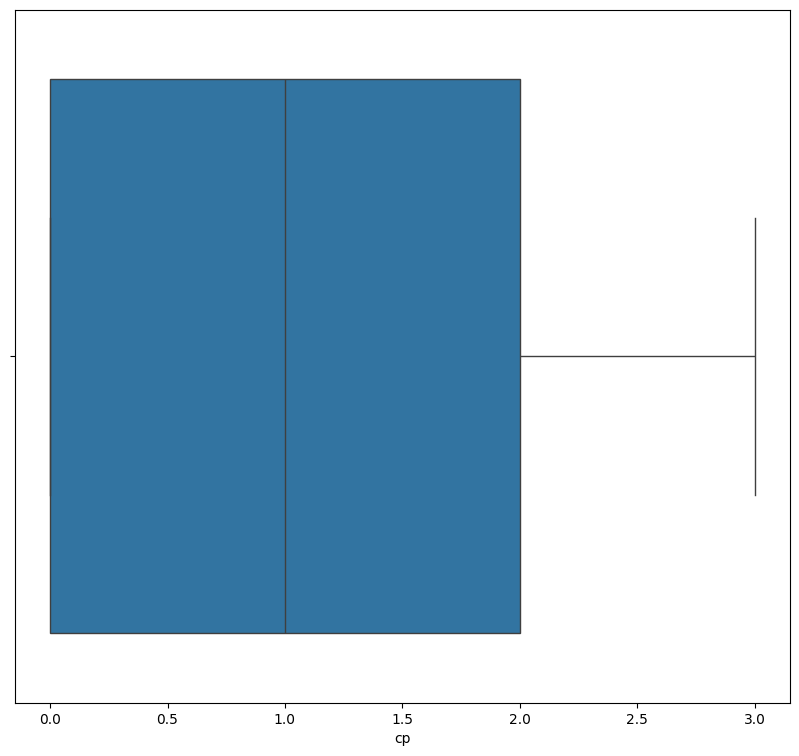

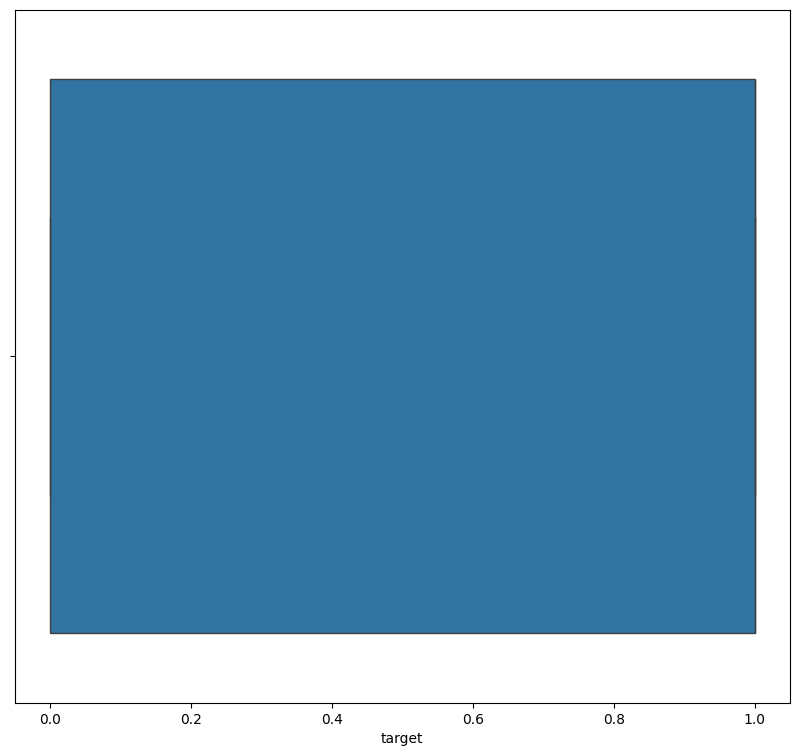

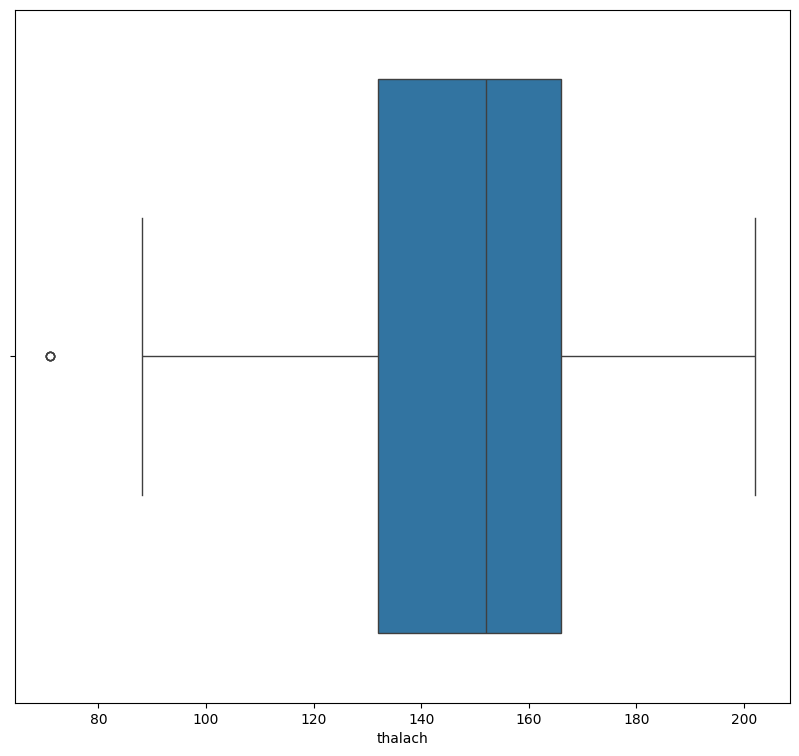

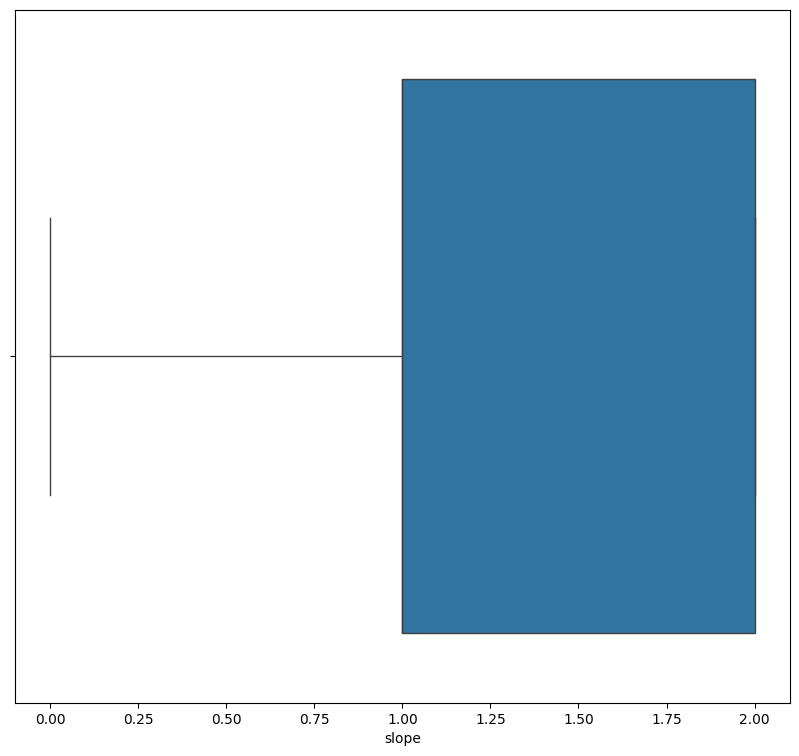

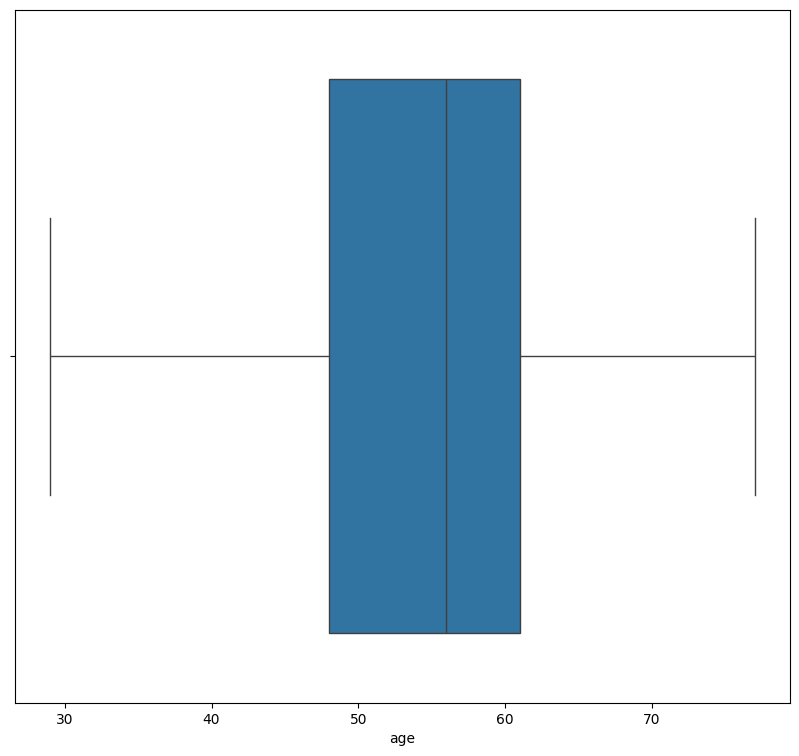

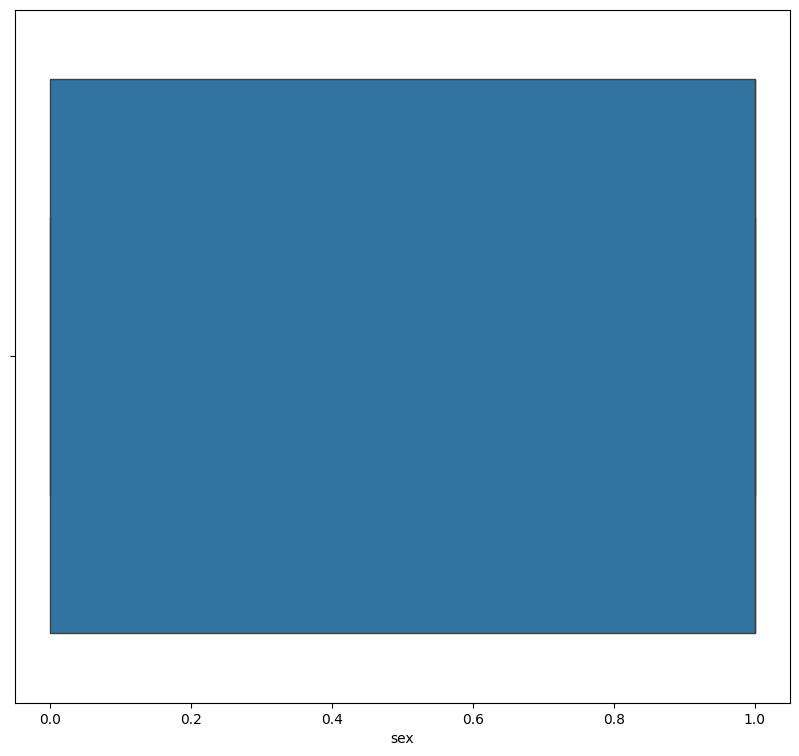

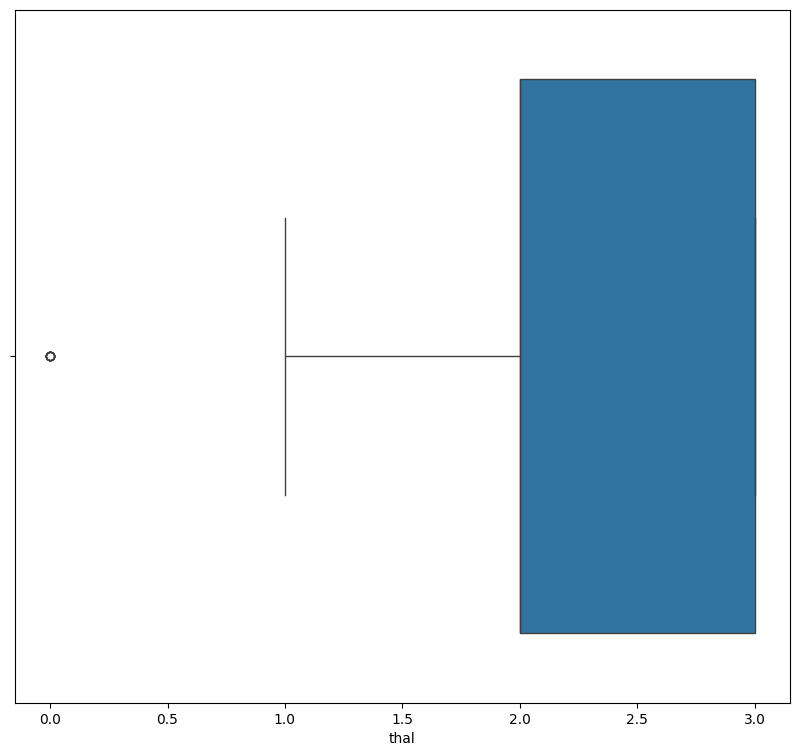

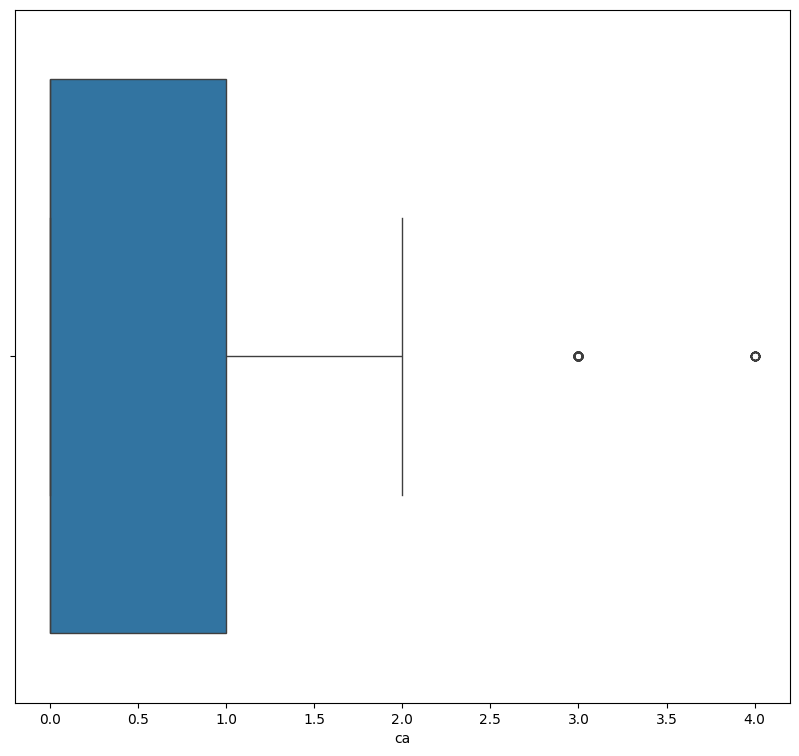

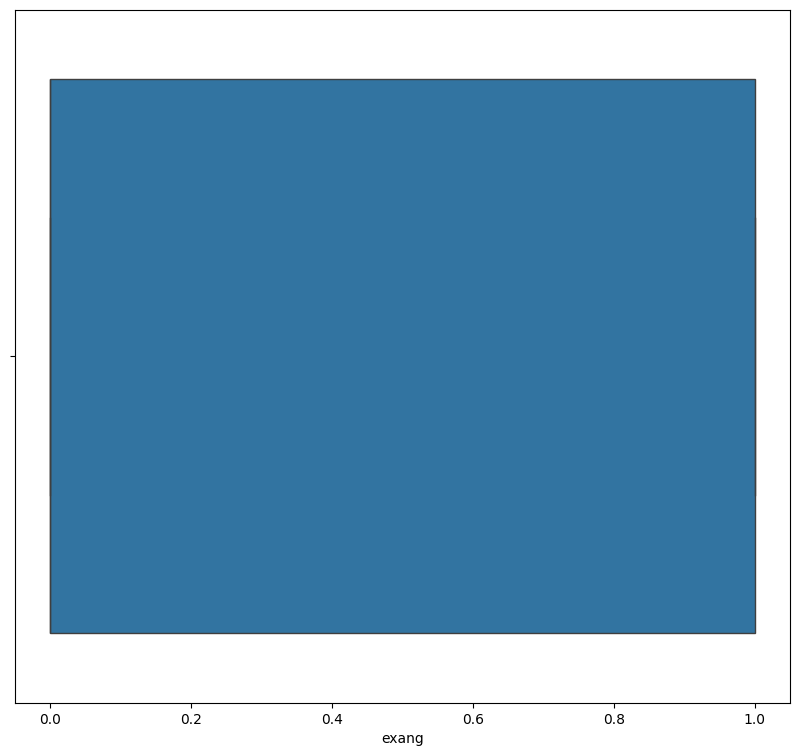

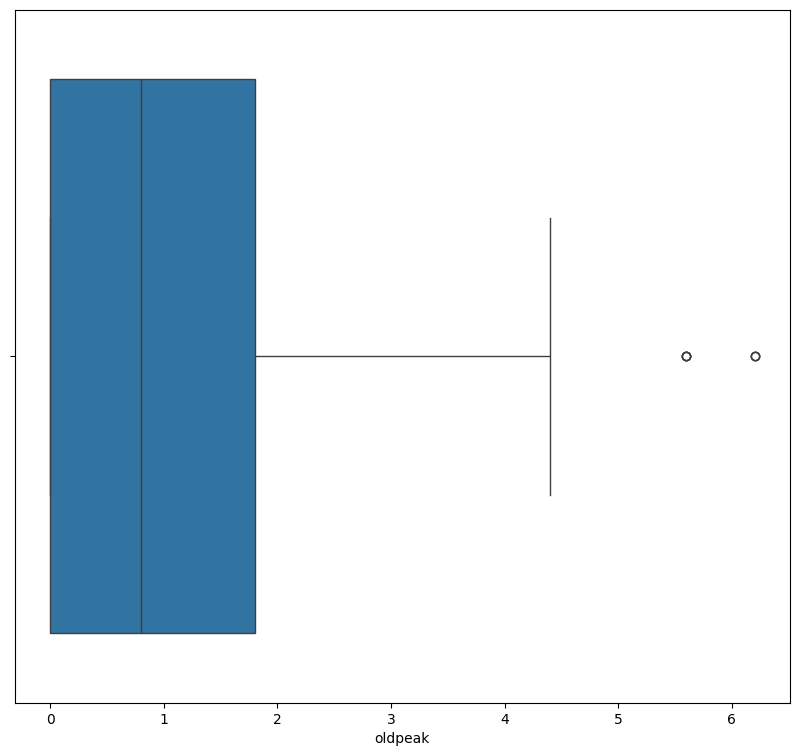

In [8]:
for feature in features:
  plt.figure(figsize=(10,9))
  sns.boxplot(data=df,x=feature)
  plt.show()

Vemos muy pocos outliers, sin embargo, vemos presencia de distribuciones no normales como vimos anteriormente

## Encoding

In [9]:
import pandas as pd
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


## Escalado

In [10]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.834359,0.364875,0.930822,-1.874977,0.705408,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
